<a href="https://colab.research.google.com/github/ayesha-tubassum/fdlkdjg/blob/main/hierarchical_clustering(country_data).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [102]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [103]:
df = pd.read_csv("/content/Country-data.csv")

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [104]:
df.shape

(167, 10)

In [105]:
df.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [107]:
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


In [108]:
df.duplicated().sum()

np.int64(0)

In [109]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [110]:
countries = df['country']

df = df.drop('country', axis=1)

In [111]:
df.sample(10)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
40,111.0,50.6,5.30,43.3,2690,5.390,56.3,5.27,1220
99,97.4,50.7,4.41,61.2,3320,18.900,68.2,4.98,1200
39,10.2,33.2,10.90,35.0,13000,6.570,80.4,1.92,8200
135,3.2,64.3,9.41,62.9,28700,-0.987,79.5,1.57,23400
100,15.0,51.2,6.00,62.2,15900,1.130,73.4,1.57,8000
157,8.6,77.7,3.66,63.6,57600,12.500,76.5,1.87,35000
111,6.2,30.3,10.10,28.0,32300,3.730,80.9,2.17,33700
139,3.8,25.5,9.54,26.8,32500,0.160,81.9,1.37,30700
82,10.8,66.7,2.63,30.4,75200,11.200,78.2,2.21,38500
77,3.2,15.0,9.49,13.6,35800,-1.900,82.8,1.39,44500


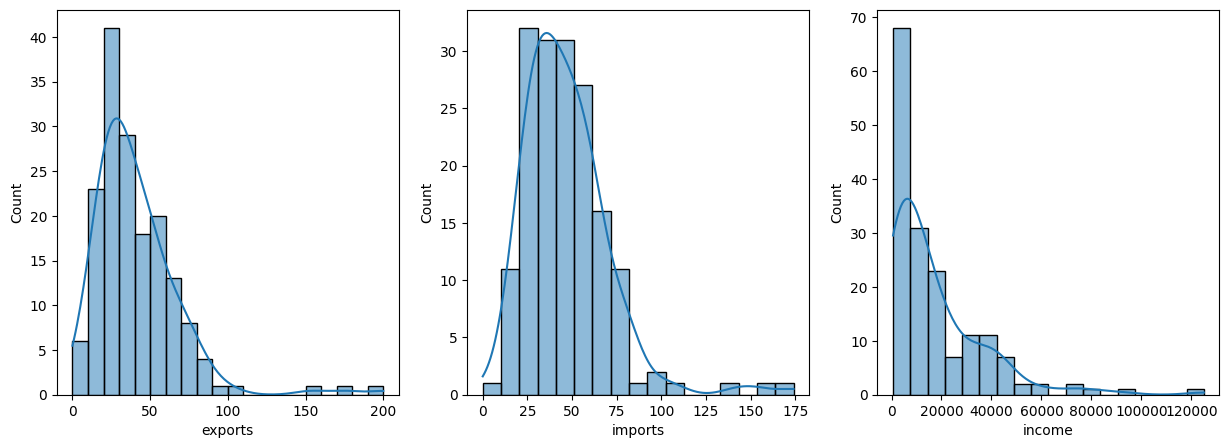

In [112]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.histplot(df['exports'], kde=True)

plt.subplot(1,3,2)
sns.histplot(df['imports'], kde=True)

plt.subplot(1,3,3)
sns.histplot(df['income'], kde=True)

plt.show()

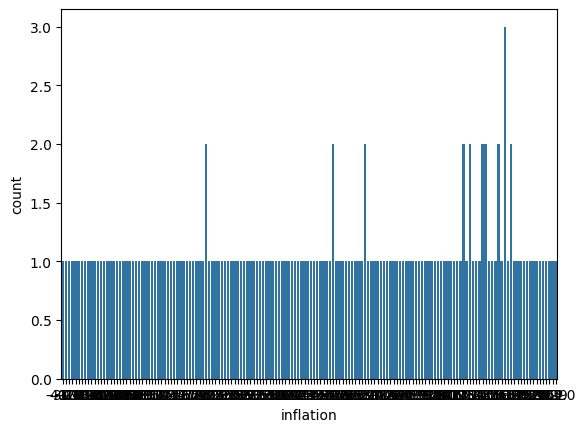

In [113]:
sns.countplot(x='inflation', data=df)
plt.show()

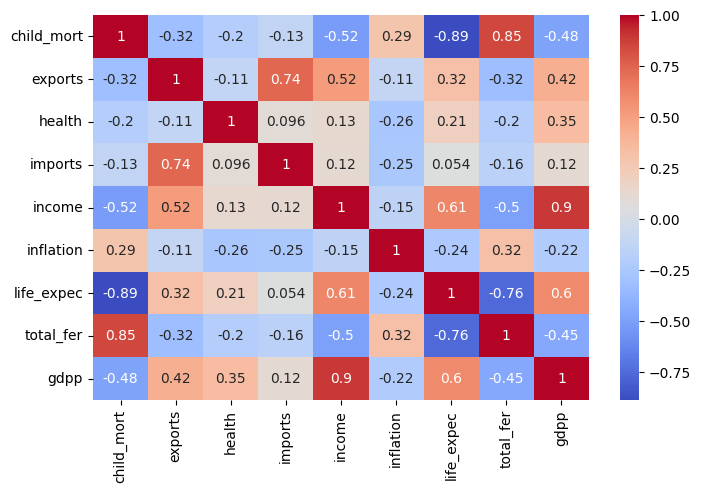

In [114]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,5))

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.show()

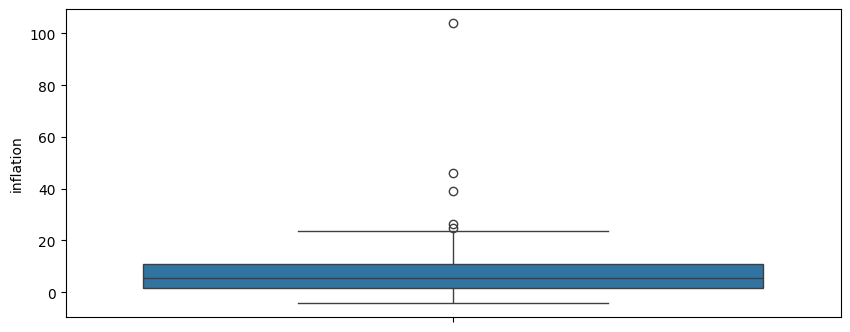

In [115]:
plt.figure(figsize=(10,4))

sns.boxplot(df['inflation'])

plt.show()

In [116]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

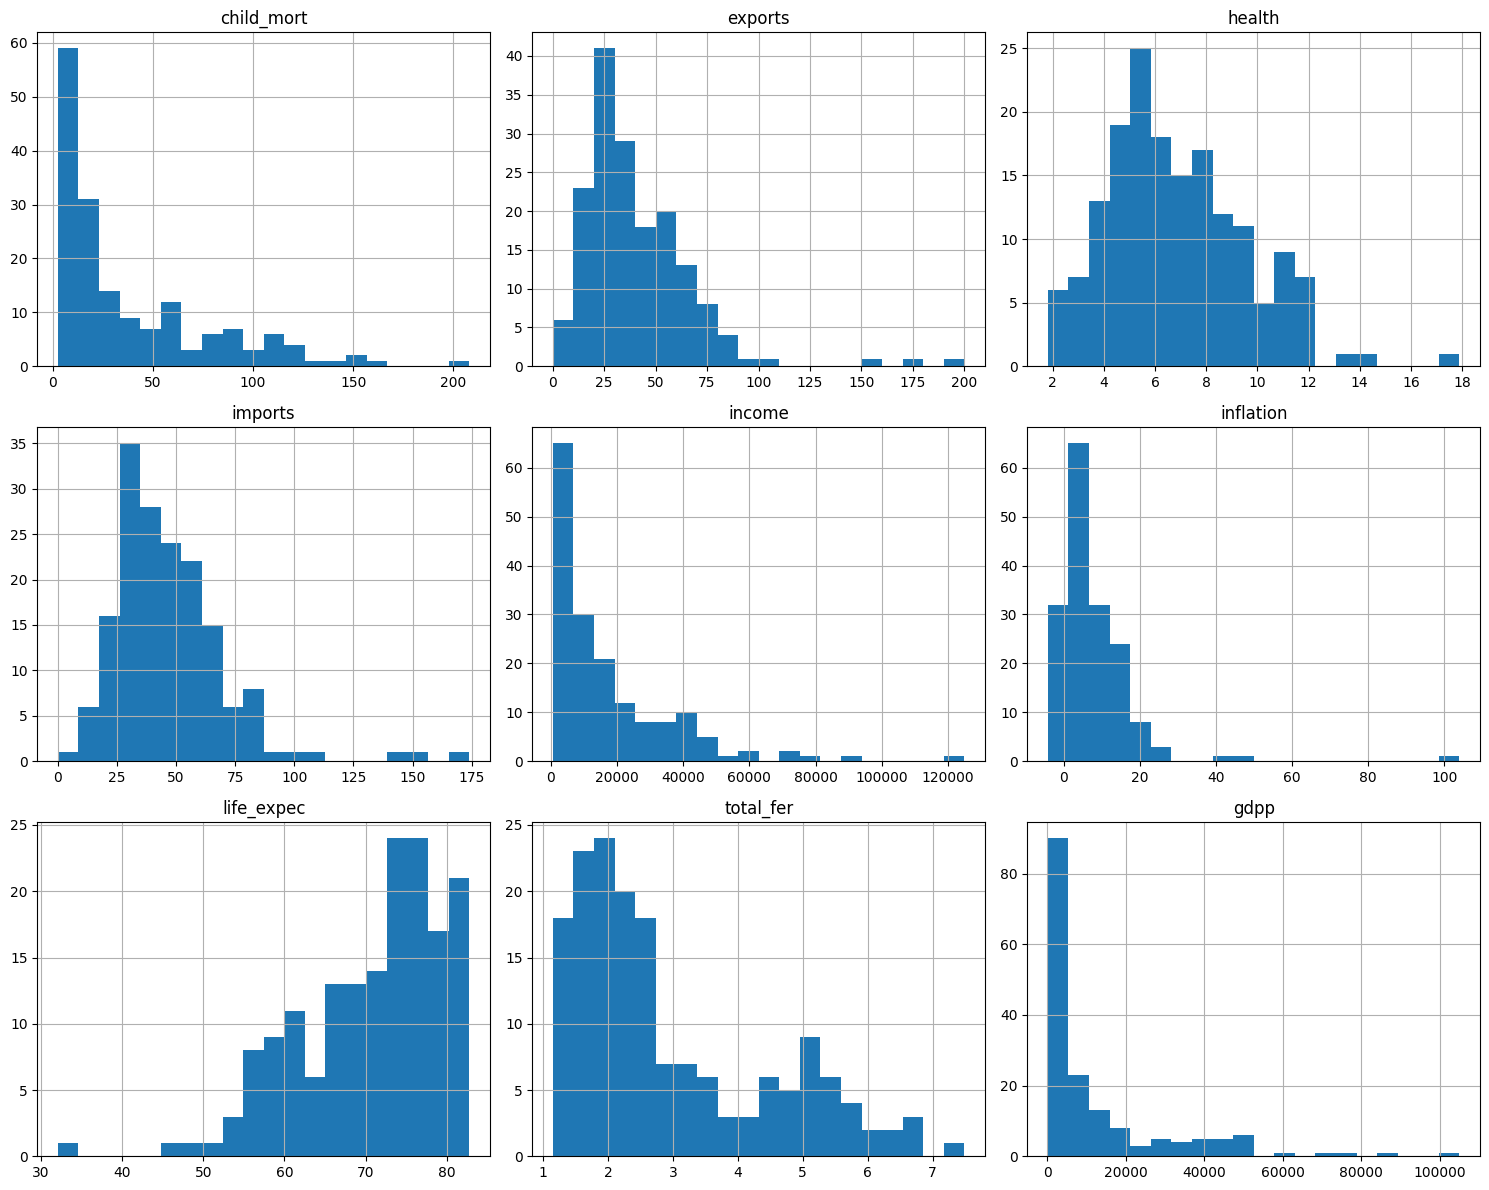

In [117]:
df.hist(figsize=(15,12), bins=20)

plt.tight_layout()

plt.show()

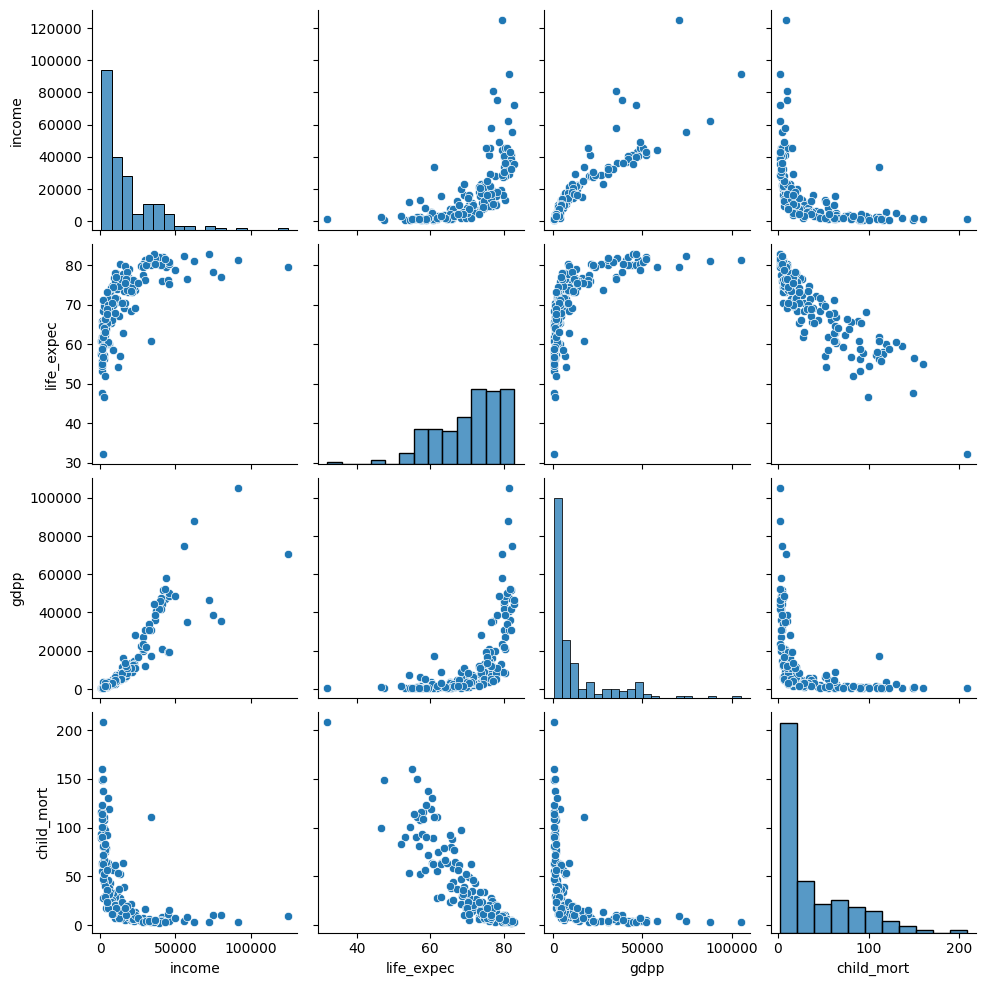

In [118]:
sns.pairplot(df[['income','life_expec','gdpp','child_mort']])

plt.show()

In [119]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

In [120]:
X_scaled[:5]

array([[ 1.29153238, -1.13827979,  0.27908825, -0.08245496, -0.8082454 ,
         0.15733622, -1.61909203,  1.90288227, -0.67917961],
       [-0.5389489 , -0.47965843, -0.09701618,  0.07083669, -0.3753689 ,
        -0.31234747,  0.64786643, -0.85997281, -0.48562324],
       [-0.27283273, -0.09912164, -0.96607302, -0.64176233, -0.22084447,
         0.78927429,  0.67042323, -0.0384044 , -0.46537561],
       [ 2.00780766,  0.77538117, -1.44807093, -0.16531531, -0.58504345,
         1.38705353, -1.17923442,  2.12815103, -0.51626829],
       [-0.69563412,  0.1606679 , -0.28689415,  0.4975675 ,  0.10173177,
        -0.60174853,  0.70425843, -0.54194633, -0.04181713]])

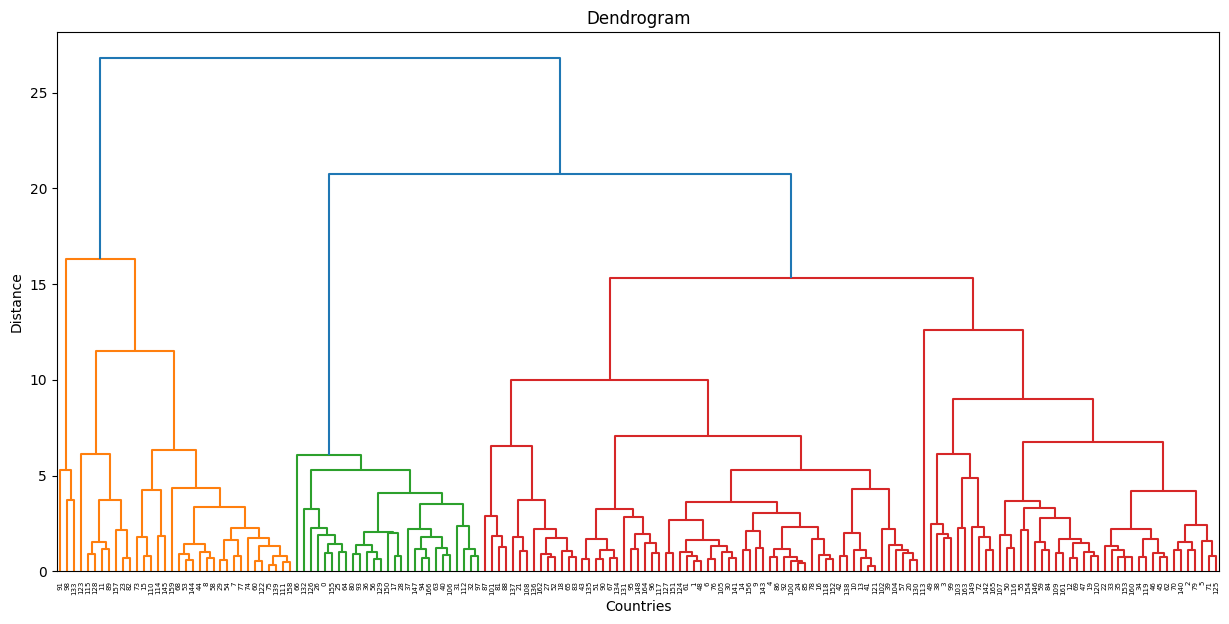

In [121]:
linked = linkage(scaled_data, method='ward')

plt.figure(figsize=(15,7))

dendrogram(linked)

plt.title("Dendrogram")
plt.xlabel("Countries")
plt.ylabel("Distance")

plt.show()

In [122]:
hc = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

In [123]:
y_hc = hc.fit_predict(X_scaled)

In [124]:
df['Cluster'] = y_hc

In [125]:
df.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,1
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,1
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,1


In [126]:
cluster_profile = df.groupby('Cluster').mean()

cluster_profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,5.961765,58.508824,8.501176,48.902941,47588.235294,4.115500,79.982353,1.888529,43170.588235
1,31.617925,39.990368,6.353679,48.085527,11341.886792,9.120604,70.921698,2.654623,6407.367925
2,105.070370,23.589630,6.507037,39.662963,1589.740741,7.142778,57.248148,5.433704,667.888889


In [127]:
hc = AgglomerativeClustering(n_clusters=3)

clusters = hc.fit_predict(scaled_data)

df['Cluster'] = clusters

In [128]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'])

pca_df['Cluster'] = clusters

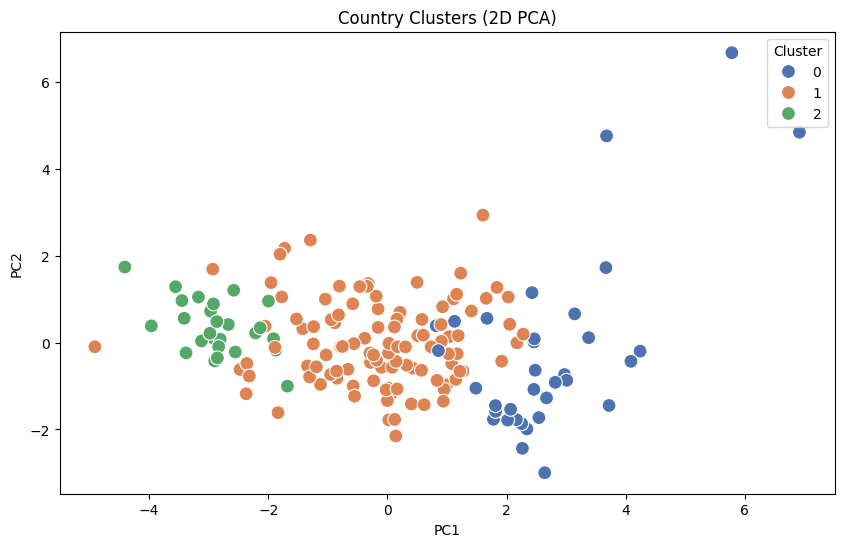

In [129]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='deep',
    data=pca_df,
    s=100
)

plt.title("Country Clusters (2D PCA)")

plt.show()

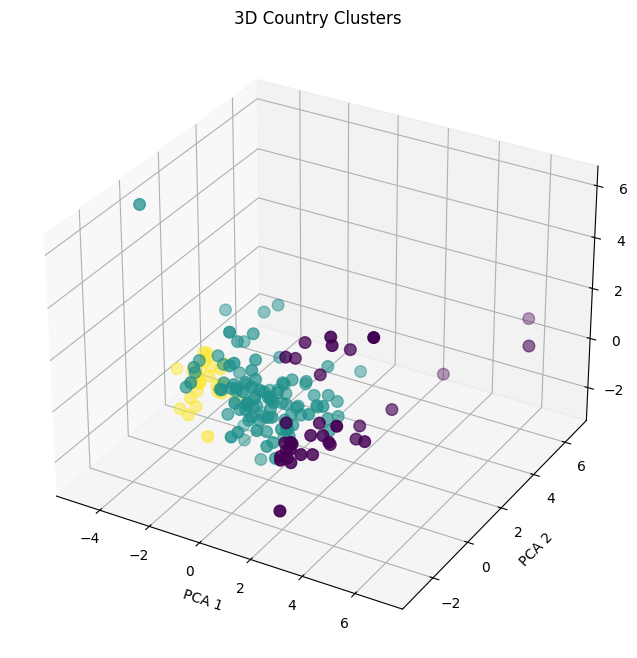

In [130]:
from mpl_toolkits.mplot3d import Axes3D

pca_3d = PCA(n_components=3)

pca_data_3d = pca_3d.fit_transform(scaled_data)

fig = plt.figure(figsize=(12,8))

ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    pca_data_3d[:,0],
    pca_data_3d[:,1],
    pca_data_3d[:,2],
    c=clusters,
    cmap='viridis',
    s=70
)

ax.set_title("3D Country Clusters")

ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")

plt.show()

In [131]:
df['Country'] = countries

In [132]:
df.sample(5)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster,Country
129,66.8,24.9,5.66,40.3,2180,1.85,64.0,5.06,1000,2,Senegal
143,24.1,52.5,7.01,38.4,14200,7.20,70.3,2.52,8300,1,Suriname
98,6.8,153.0,8.65,154.0,28300,3.83,80.3,1.36,21100,0,Malta
32,150.0,36.8,4.53,43.5,1930,6.39,56.5,6.59,897,2,Chad
101,40.0,23.5,14.20,81.0,3340,3.80,65.4,3.46,2860,1,"Micronesia, Fed. Sts."


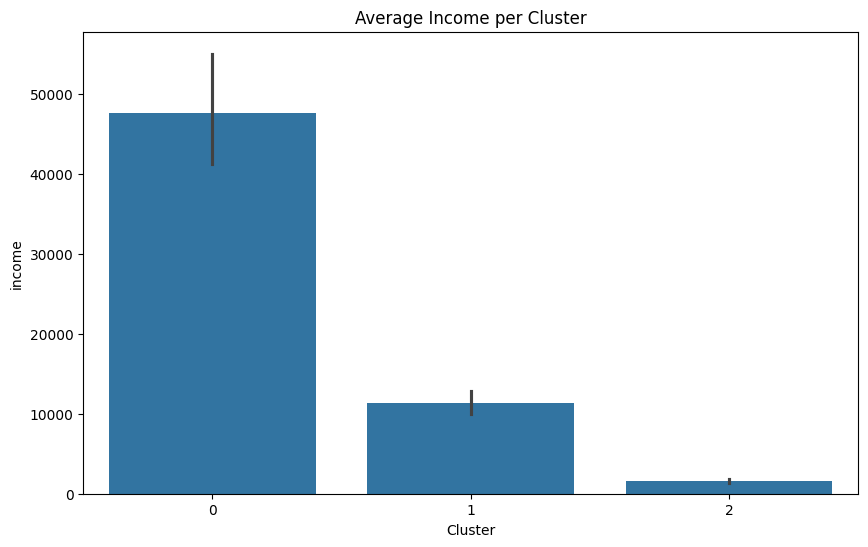

In [133]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Cluster',
    y='income',
    data=df
)

plt.title("Average Income per Cluster")

plt.show()

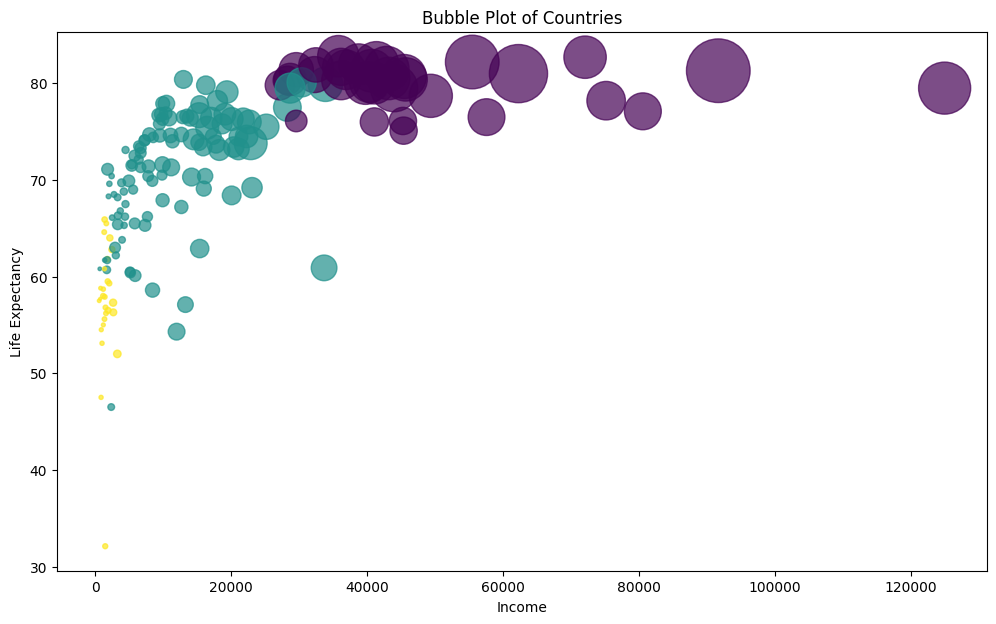

In [134]:
plt.figure(figsize=(12,7))

plt.scatter(
    df['income'],
    df['life_expec'],
    s=df['gdpp']/50,
    c=df['Cluster'],
    cmap='viridis',
    alpha=0.7
)

plt.xlabel("Income")
plt.ylabel("Life Expectancy")

plt.title("Bubble Plot of Countries")

plt.show()

In [135]:
df['income'] = np.log1p(df['income'])

df['gdpp'] = np.log1p(df['gdpp'])

In [136]:
score = silhouette_score(scaled_data, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.24563001303300652


In [137]:
scores = []

for i in range(2, 10):

    hc = AgglomerativeClustering(n_clusters=i)

    labels = hc.fit_predict(scaled_data)

    score = silhouette_score(scaled_data, labels)

    scores.append(score)

    print("Clusters:", i, "Score:", score)

Clusters: 2 Score: 0.3153134331018189
Clusters: 3 Score: 0.24563001303300652
Clusters: 4 Score: 0.24811891847692066
Clusters: 5 Score: 0.2193301598939687
Clusters: 6 Score: 0.217674980548791
Clusters: 7 Score: 0.24187376443876954
Clusters: 8 Score: 0.23387000967791902
Clusters: 9 Score: 0.23713495817822783


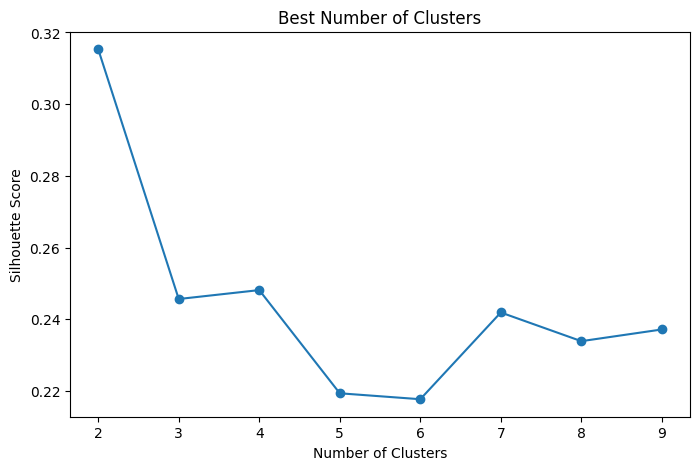

In [138]:
plt.figure(figsize=(8,5))

plt.plot(range(2,10), scores, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

plt.title("Best Number of Clusters")

plt.show()